# Price Plot Gallery

Price plots are bubble charts that show how products distribute across price bands for different groups, like retailers, categories, or regions. Each row of the chart is a price band; each column is a group; bubble size is the share of that group's products falling in that band.

Price plots excel at:
- **Price architecture**: see at a glance whether a retailer is anchored in the budget, mid, or premium tier
- **Competitive positioning**: read entire pricing strategies side by side without flipping between charts
- **Category mix**: understand where each category sits on the price ladder
- **White-space detection**: empty cells mark price bands no one is competing in

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from openretailscience.plots import price

In [ ]:
# Hand-crafted demo datasets shared across the gallery examples.
# Each retailer/category has a deliberate price distribution so the bubble pattern
# tells a clear pricing story.

# ----- Equal-width bins example -----
# Four UK retailers across six $20-wide bands spanning $10 to $130.
# Counts per bin per retailer are designed to make each retailer's strategy
# legible at a glance: Aldi anchors low, Waitrose anchors high, Tesco and M&S
# tilt mid and mid-premium respectively.
_retailer_bin_midpoints = [20, 40, 60, 80, 100, 120]
_retailer_counts = {
    "Aldi": [50, 30, 12, 5, 2, 1],
    "Tesco": [5, 15, 30, 28, 15, 7],
    "M&S": [2, 8, 18, 30, 28, 14],
    "Waitrose": [1, 4, 10, 20, 32, 33],
}
_retailer_rows = []
for retailer, counts in _retailer_counts.items():
    for midpoint, count in zip(_retailer_bin_midpoints, counts, strict=True):
        _retailer_rows.extend([{"retailer": retailer, "price": float(midpoint)}] * count)
retailer_prices = pd.DataFrame(_retailer_rows)
retailer_prices.insert(0, "product_id", range(1, len(retailer_prices) + 1))

# ----- Custom bin boundaries example -----
# Four product categories across six business-defined price tiers.
# Apparel concentrates in the value tiers, Electronics in the premium tiers,
# Home and Sports straddle the middle.
_category_bins = [0, 25, 50, 75, 100, 150, 200]
_category_bin_midpoints = [12, 37, 62, 87, 125, 175]
_category_counts = {
    "Apparel": [50, 45, 15, 6, 3, 1],
    "Home": [8, 22, 35, 25, 8, 2],
    "Sports": [5, 15, 30, 30, 18, 2],
    "Electronics": [2, 8, 15, 20, 35, 20],
}
_category_rows = []
for category, counts in _category_counts.items():
    for midpoint, count in zip(_category_bin_midpoints, counts, strict=True):
        _category_rows.extend([{"category": category, "price": float(midpoint)}] * count)
category_prices = pd.DataFrame(_category_rows)
category_prices.insert(0, "product_id", range(1, len(category_prices) + 1))

## Equal-Width Price Bins

Pass an integer to `bins` and the plot creates that many equal-width price bands using `pandas.cut`. Useful when you want to see the raw shape of a distribution without imposing business-specific cutoffs. The bin edges fall wherever the data range happens to land, so the labels reflect the actual data rather than rounded thresholds.

The bubble size for each cell is the share of that group's products falling in that price band, so columns are individually normalised. A big bubble at the top of one column means "this retailer concentrates here" — it is not directly comparable to a same-sized bubble in a column with very different total volume.

---

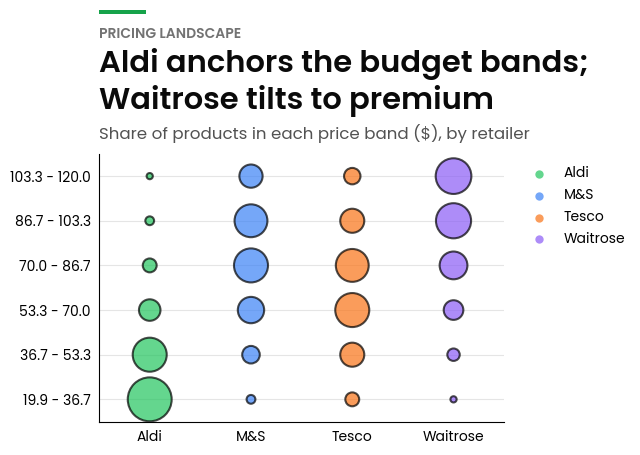

In [ ]:
price.plot(
    retailer_prices,
    value_col="price",
    group_col="retailer",
    bins=6,
    eyebrow="Pricing landscape",
    title="Aldi anchors the budget bands; Waitrose tilts to premium",
    subtitle="Share of products in each price band ($), by retailer",
    move_legend_outside=True,
)
plt.show()

## Custom Price Bin Boundaries

Pass a list of edge values to `bins` to define your own price tiers. Use this when the business already thinks in specific bands (e.g. value, opening price point, mid, premium, super-premium) and you want the chart to reflect that vocabulary. The list is sorted internally, so order does not matter.

Custom edges also let you make the chart asymmetric — wider bands at the top of the range where products are sparser, narrower bands where the action is. The example below uses six tiers with two wider top bands so the premium tail does not get split into too many sparse rows.

---

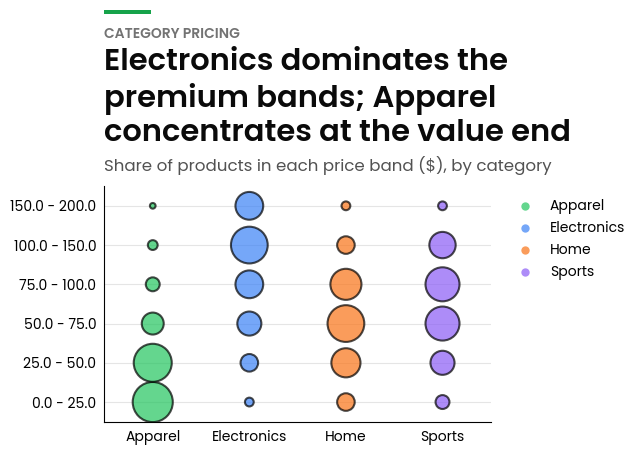

In [ ]:
price.plot(
    category_prices,
    value_col="price",
    group_col="category",
    bins=[0, 25, 50, 75, 100, 150, 200],
    eyebrow="Category pricing",
    title="Electronics dominates the premium bands; Apparel concentrates at the value end",
    subtitle="Share of products in each price band ($), by category",
    move_legend_outside=True,
)
plt.show()

## Axis Labels and Source Attribution

Add `x_label`, `y_label`, and `source_text` to make the chart export-ready. The y-axis label is helpful here because the row labels are price ranges rather than a single quantity, so a short "Price band ($)" tells the reader what they are reading. `source_text` renders a small attribution at the foot of the chart for slides and reports.

`legend_title` overrides the default legend header (the column name) with a more readable label. Pair this with `move_legend_outside=True` to keep the bubbles uncluttered.

---

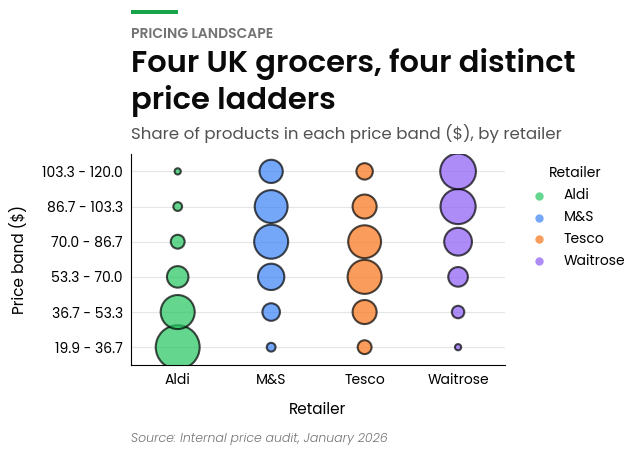

In [ ]:
price.plot(
    retailer_prices,
    value_col="price",
    group_col="retailer",
    bins=6,
    eyebrow="Pricing landscape",
    title="Four UK grocers, four distinct price ladders",
    subtitle="Share of products in each price band ($), by retailer",
    x_label="Retailer",
    y_label="Price band ($)",
    legend_title="Retailer",
    move_legend_outside=True,
    source_text="Source: Internal price audit, January 2026",
)
plt.show()